<a href="https://colab.research.google.com/github/Kartel7/Murmansk_SnowCover/blob/main/Solid_precipitation_receiving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

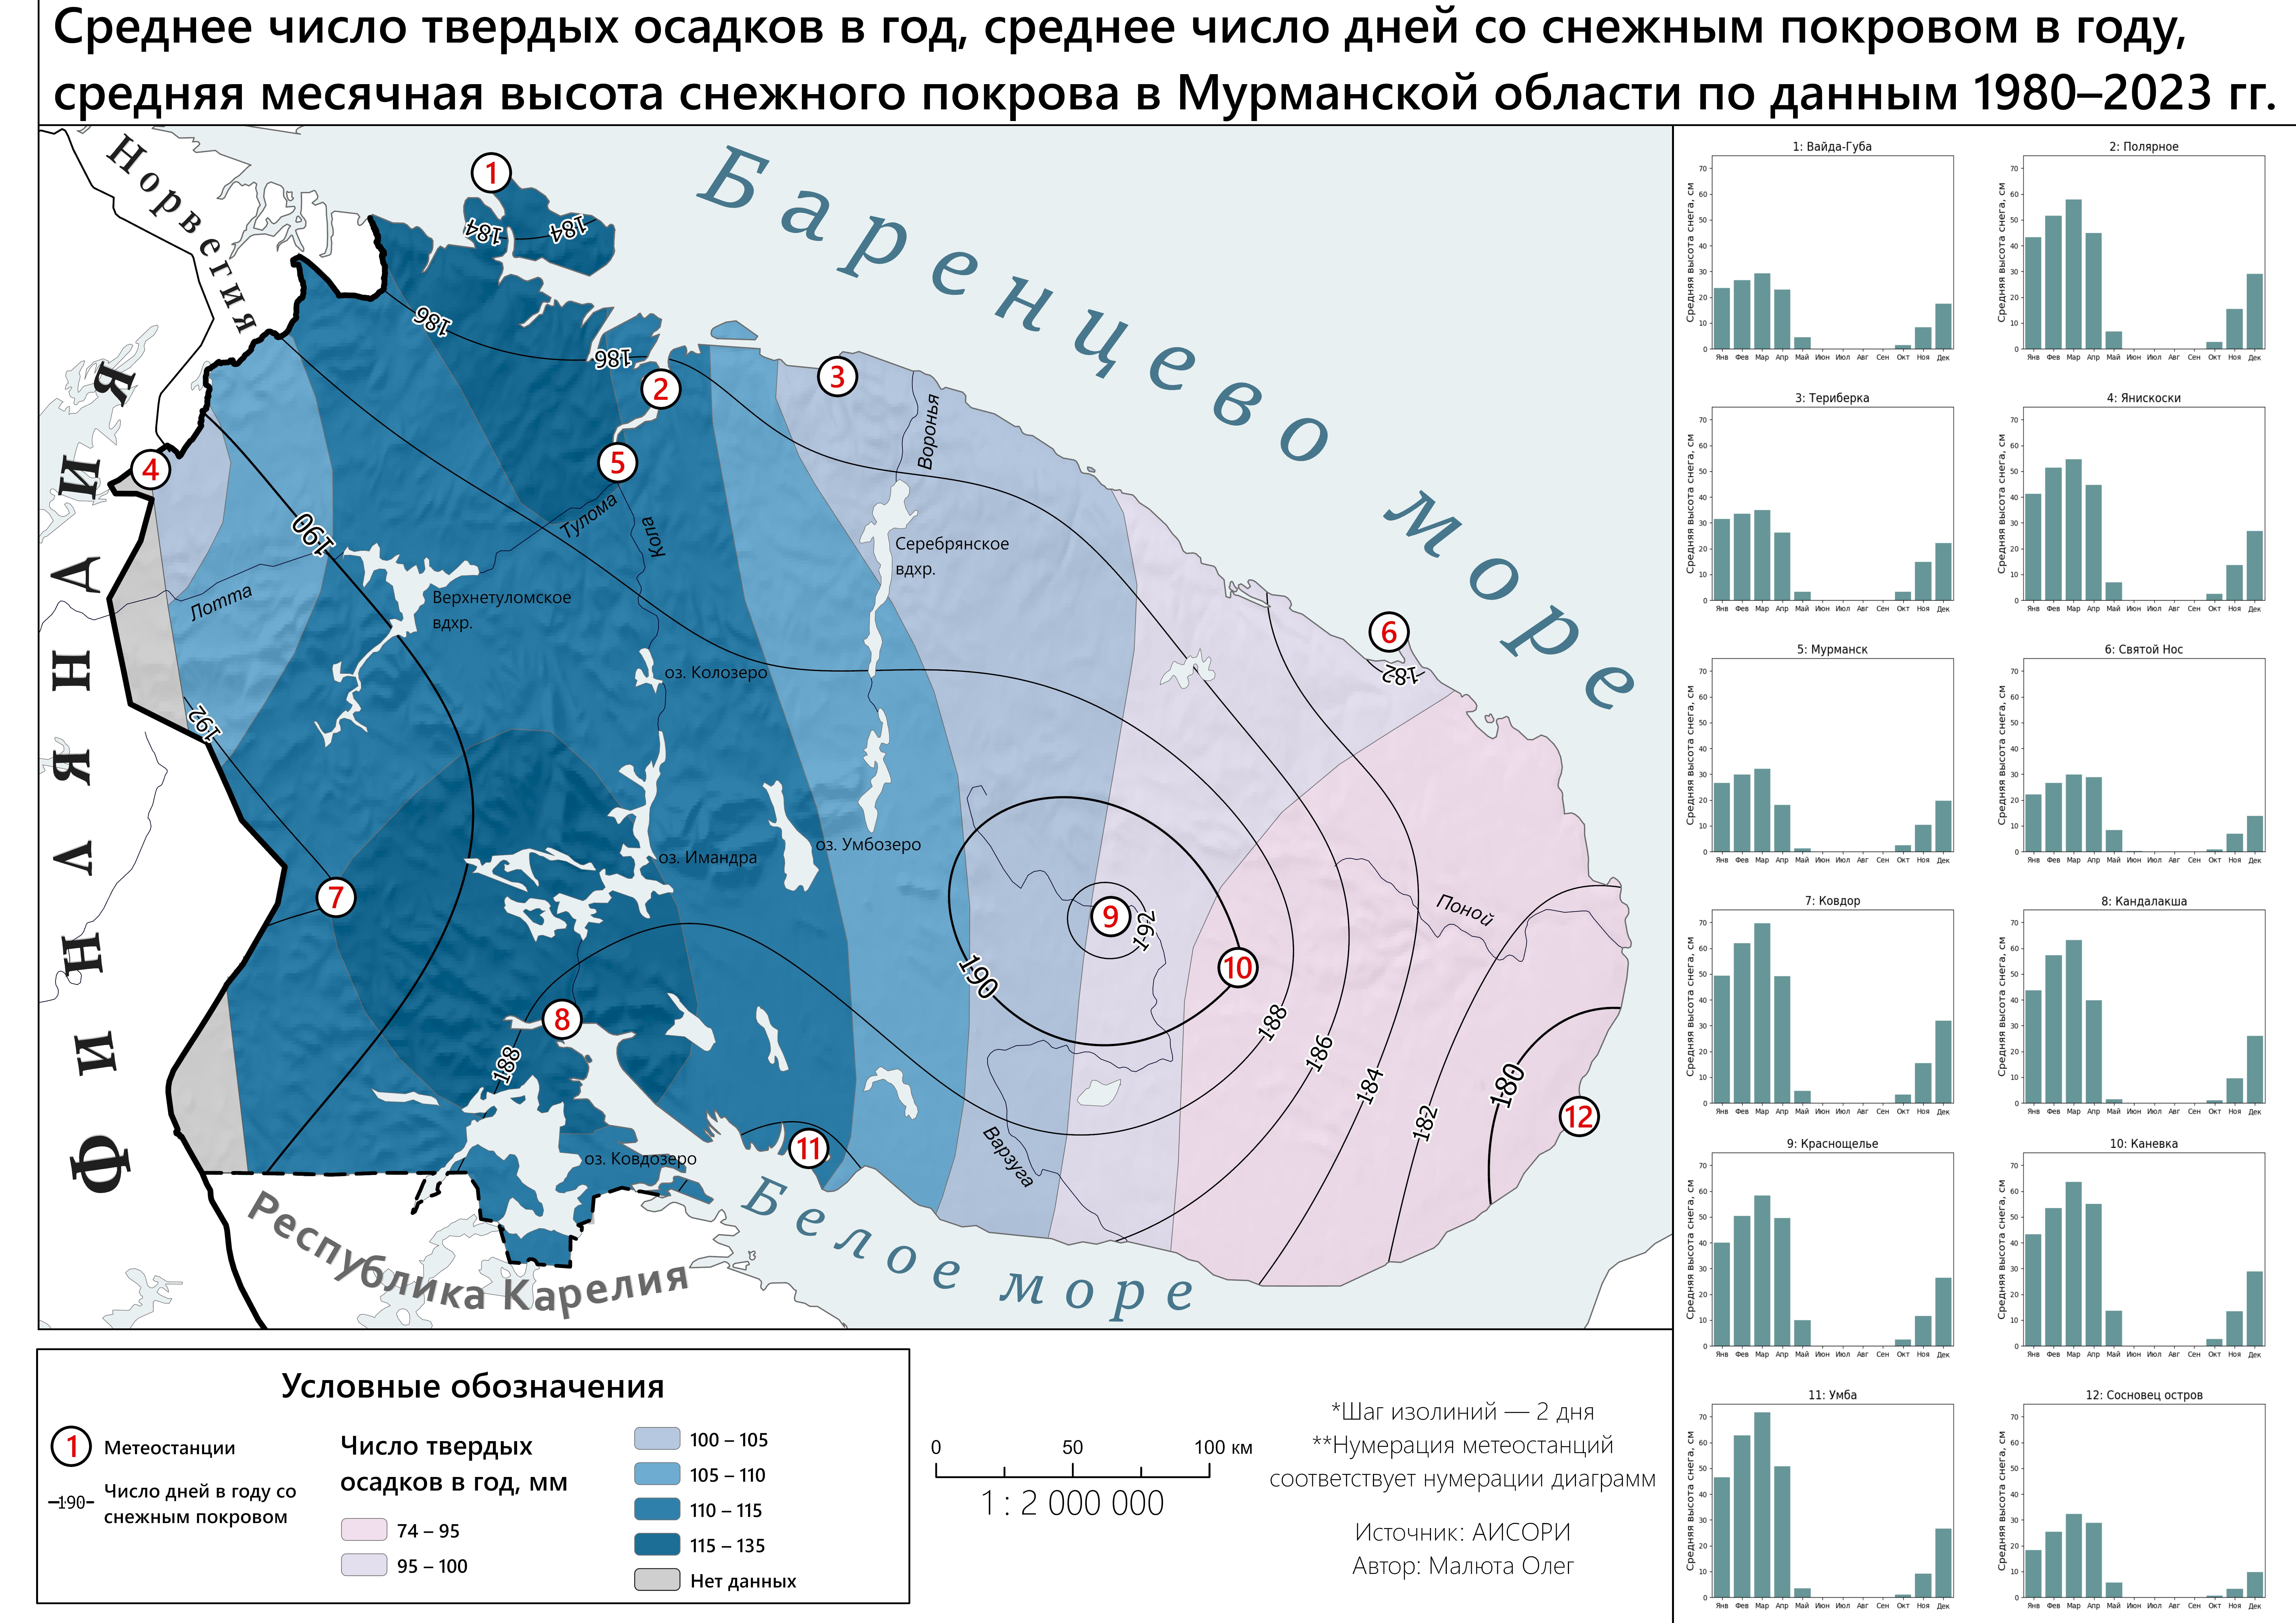

Полученные данные были интерполированы в ГИС для визуализации

# НАЧАЛО

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
from datetime import datetime

In [ ]:
os.chdir(r"C:\Users\malyu\OneDrive\Рабочий стол\Нужное\ВШЭ работы\нис\КАРТА НИС\Summesc(Snow_amount)\Summesc")

Данные: http://aisori-m.meteo.ru/

Обрабатываем метеостанции по Мурманской области для карты

In [ ]:
# Исходные данные
files = os.listdir()
files

['22003.dat',
 '22019.dat',
 '22113.dat',
 '22140.dat',
 '22204.dat',
 '22217.dat',
 '22235.dat',
 '22249.dat',
 '22355.dat',
 '22408.dat',
 'results']

In [ ]:
if not os.path.exists('results'):
    os.mkdir('results')

# Цикл для экспорта количества твердых осадков в мм для станций в среднем за последние 35 лет

In [ ]:
meanprec = {}

for filename in files:

    if filename[-4:] == '.dat':

        # Получаем количество твердых осадков за зимние месяцы всех лет для каждой станции
        df = pd.read_csv(filename, sep='\s+', header=None)
        df.columns = ['Индекс', 'Год', 'Месяц', 'Признак полноты', 'М сум', 'М сум скор', 'М сум ж', 'М сум см', 'М сум тв']
        df = df[(df['Месяц'].isin([1,2,12])) & (df['Год']>=1980)]
        df = df[df['М сум см']<9000]
        groupdf = df.groupby('Год').sum()
        groupdf = groupdf[groupdf['Месяц']==15]
        meanprec[df['Индекс'].iloc[0]] = groupdf['М сум тв'].mean()

SA = pd.Series(data=meanprec, index=meanprec.keys())
SA.name = 'Количество твердых осадков в мм'

SA.to_csv(r"results\Количество твердых осадков в мм.csv", encoding='UTF-8')

In [ ]:
# Итоговая общая сводная таблица с количеством твердых осадков в мм для станций Мурманской области

SA

22003    135.302857
22019    117.815152
22113    123.696970
22140    101.093548
22204    119.677143
22217    125.709375
22235     99.914706
22249     86.630000
22355     73.009677
22408     96.113889
Name: Количество твердых осадков в мм, dtype: float64

# КОНЕЦ

# Ниже описание обработки данных на примере одной станции

In [ ]:
# Словарь, куда будем записывать индекс станции и количество твердых осадков

meanprec = {}

In [ ]:
# Входные данные: ежемесячное количество осадков по одной станции

df = pd.read_csv(r"C:\Users\malyu\OneDrive\Рабочий стол\Нужное\ВШЭ работы\нис\КАРТА НИС\Summesc(Snow_amount)\Summesc\22003.dat", sep='\s+', header=None)

In [ ]:
# Задаем нормальные название колонок

df.columns = ['Индекс', 'Год', 'Месяц', 'Признак полноты', 'М сум', 'М сум скор', 'М сум ж', 'М сум см', 'М сум тв']

In [ ]:
df

,Индекс,Год,Месяц,Признак полноты,М сум,М сум скор,М сум ж,М сум см,М сум тв
0,22003,1940,5,0,11.0,16.4,12.1,0.1,4.2
1,22003,1940,6,0,53.6,62.9,62.9,0.0,0.0
2,22003,1940,7,9,9999.9,9999.9,9999.9,9999.9,9999.9
3,22003,1940,8,0,87.6,104.6,101.5,0.2,2.8
4,22003,1940,9,0,29.8,36.9,36.8,0.1,0.0
...,...,...,...,...,...,...,...,...,...
903,22003,2015,8,0,46.1,49.3,49.3,0.0,0.0
904,22003,2015,9,0,35.3,38.3,38.3,0.0,0.0
905,22003,2015,10,0,32.3,36.3,29.6,5.5,1.2
906,22003,2015,11,0,33.0,38.1,18.0,9.9,10.1


In [ ]:
# Берем только зимние месяцы и данные с 1980 года

df = df[(df['Месяц'].isin([1,2,12])) & (df['Год']>=1980)]

In [ ]:
# В этом случае всего 2 некорректных значения

len(df[df['М сум см'] > 1000])

2

In [ ]:
# Убираем некорректные значения

df = df[df['М сум см']<9000]

In [ ]:
# Суммируем осадки внутри года

groupdf = df.groupby('Год').sum()

In [ ]:
groupdf

,Индекс,Месяц,Признак полноты,М сум,М сум скор,М сум ж,М сум см,М сум тв
Год,,,,,,,,
1980,66009,15,0,95.8,112.7,4.3,4.2,104.2
1981,66009,15,0,96.9,95.5,0.0,2.5,92.9
1982,66009,15,0,134.4,172.2,20.5,4.2,147.7
1983,66009,15,0,159.7,193.8,35.7,13.5,144.6
1984,66009,15,0,81.9,100.4,19.3,7.3,73.9
1985,66009,15,0,151.3,227.6,0.4,3.2,224.0
1986,66009,15,0,163.6,211.2,3.9,0.9,206.3
1987,66009,15,0,166.6,228.5,7.1,1.0,220.3
1988,66009,15,0,94.5,141.4,6.6,8.2,126.7


Пояснение: в конце мы усредним данные по всем годам, поэтому нам не важно, что один сезон зимы включает 2 смежных года

In [ ]:
# Оставляем только полные данные (1 + 2 + 12 = 15)

groupdf = groupdf[groupdf['Месяц']==15]

In [ ]:
groupdf

,Индекс,Месяц,Признак полноты,М сум,М сум скор,М сум ж,М сум см,М сум тв
Год,,,,,,,,
1980,66009,15,0,95.8,112.7,4.3,4.2,104.2
1981,66009,15,0,96.9,95.5,0.0,2.5,92.9
1982,66009,15,0,134.4,172.2,20.5,4.2,147.7
1983,66009,15,0,159.7,193.8,35.7,13.5,144.6
1984,66009,15,0,81.9,100.4,19.3,7.3,73.9
1985,66009,15,0,151.3,227.6,0.4,3.2,224.0
1986,66009,15,0,163.6,211.2,3.9,0.9,206.3
1987,66009,15,0,166.6,228.5,7.1,1.0,220.3
1988,66009,15,0,94.5,141.4,6.6,8.2,126.7


In [ ]:
# Данные за 35 полных лет

len(groupdf)

35

In [ ]:
# Средние твердые осадки для одной станции

groupdf['М сум тв'].mean()

135.30285714285714

In [ ]:
# Наполняем словарь данными по одной станции

meanprec[df['Индекс'].unique()[0]] = groupdf['М сум тв'].mean()
meanprec

{22003: 135.30285714285714}

In [ ]:
pd.Series(meanprec)

22003    135.302857
dtype: float64